In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maxhorowitz/nflplaybyplay2009to2016")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nflplaybyplay2009to2016' dataset.
Path to dataset files: /kaggle/input/nflplaybyplay2009to2016


In [2]:
import pandas as pd

# Import dataframe
df = pd.read_csv(path + "/NFL Play by Play 2009-2017 (v4).csv")
df.head(10)

/tmp/ipython-input-4024366084.py:4: DtypeWarning: Columns (25,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + "/NFL Play by Play 2009-2017 (v4).csv")


,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,NaN,15:00,15,3600.0,0.0,TEN,...,NaN,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,NaN,NaN,2009
1,2009-09-10,2009091000,1,1,1.0,14:53,15,3593.0,7.0,PIT,...,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,2009-09-10,2009091000,1,1,2.0,14:16,15,3556.0,37.0,PIT,...,NaN,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,NaN,NaN,2009
3,2009-09-10,2009091000,1,1,3.0,13:35,14,3515.0,41.0,PIT,...,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2009-09-10,2009091000,1,1,4.0,13:27,14,3507.0,8.0,PIT,...,NaN,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,NaN,NaN,2009
5,2009-09-10,2009091000,2,1,1.0,13:16,14,3496.0,11.0,TEN,...,NaN,0.558929,0.441071,0.578453,0.421547,0.441071,-0.019524,NaN,NaN,2009
6,2009-09-10,2009091000,2,1,2.0,12:40,13,3460.0,36.0,TEN,...,0.163935,0.578453,0.421547,0.582881,0.417119,0.421547,-0.004427,-0.010456,0.006029,2009
7,2009-09-10,2009091000,2,1,3.0,12:11,13,3431.0,29.0,TEN,...,NaN,0.582881,0.417119,0.617544,0.382456,0.417119,-0.034663,NaN,NaN,2009
8,2009-09-10,2009091000,2,1,4.0,11:34,12,3394.0,37.0,TEN,...,NaN,0.617544,0.382456,0.591489,0.408511,0.382456,0.026054,NaN,NaN,2009
9,2009-09-10,2009091000,3,1,1.0,11:24,12,3384.0,10.0,TEN,...,0.541602,0.591489,0.408511,0.585405,0.414595,0.591489,-0.006084,-0.024526,0.018442,2009


In [3]:
# Print list of columns and number of columns in dataframe for cleaning
columns = list(df.columns)
print(columns)
print(f"Number of columns in dataframe: {len(columns)}")

['Date', 'GameID', 'Drive', 'qtr', 'down', 'time', 'TimeUnder', 'TimeSecs', 'PlayTimeDiff', 'SideofField', 'yrdln', 'yrdline100', 'ydstogo', 'ydsnet', 'GoalToGo', 'FirstDown', 'posteam', 'DefensiveTeam', 'desc', 'PlayAttempted', 'Yards.Gained', 'sp', 'Touchdown', 'ExPointResult', 'TwoPointConv', 'DefTwoPoint', 'Safety', 'Onsidekick', 'PuntResult', 'PlayType', 'Passer', 'Passer_ID', 'PassAttempt', 'PassOutcome', 'PassLength', 'AirYards', 'YardsAfterCatch', 'QBHit', 'PassLocation', 'InterceptionThrown', 'Interceptor', 'Rusher', 'Rusher_ID', 'RushAttempt', 'RunLocation', 'RunGap', 'Receiver', 'Receiver_ID', 'Reception', 'ReturnResult', 'Returner', 'BlockingPlayer', 'Tackler1', 'Tackler2', 'FieldGoalResult', 'FieldGoalDistance', 'Fumble', 'RecFumbTeam', 'RecFumbPlayer', 'Sack', 'Challenge.Replay', 'ChalReplayResult', 'Accepted.Penalty', 'PenalizedTeam', 'PenaltyType', 'PenalizedPlayer', 'Penalty.Yards', 'PosTeamScore', 'DefTeamScore', 'ScoreDiff', 'AbsScoreDiff', 'HomeTeam', 'AwayTeam', 'T

In [4]:
# Drop columns from dataframe that contain information from the current play
cols_to_drop = ["Date", "time", "SideofField", "ydsnet", "FirstDown", "DefTwoPoint", "Passer", "Passer_ID", "ExpPts", "WPA", "No_Score_Prob", "Opp_Field_Goal_Prob", "Opp_Safety_Prob", "Opp_Touchdown_Prob", "Field_Goal_Prob", "Safety_Prob", "Touchdown_Prob", "ExPoint_Prob", "TwoPoint_Prob", "airEPA", "yacEPA", "Home_WP_pre", "Away_WP_pre", "Home_WP_post", "Away_WP_post", "Win_Prob", "airWPA", "yacWPA", "desc", "Yards.Gained", "Touchdown", "Safety", "Onsidekick", "PuntResult", "PlayType", "PassLength", "PassAttempt", "PassOutcome", "AirYards", "YardsAfterCatch", "QBHit", "PassLocation", "InterceptionThrown", "Interceptor", "Rusher", "Rusher_ID", "RushAttempt", "RunLocation", "RunGap", "Receiver", "Receiver_ID", "Reception", "ReturnResult", "Returner", "BlockingPlayer", "Tackler1", "Tackler2", "FieldGoalResult", "FieldGoalDistance", "Fumble", "RecFumbTeam", "RecFumbPlayer", "Sack", "Challenge.Replay", "ChalReplayResult", "Accepted.Penalty", "PenalizedTeam", "PenaltyType", "PenalizedPlayer", "Penalty.Yards", "PosTeamScore", "DefTeamScore", "ExPointResult", "TwoPointConv", "sp"]
df_clean = df.drop(columns=cols_to_drop, axis=1)

columns = list(df_clean.columns)
print(columns)
print(f"Number of columns in dataframe: {len(columns)}")

['GameID', 'Drive', 'qtr', 'down', 'TimeUnder', 'TimeSecs', 'PlayTimeDiff', 'yrdln', 'yrdline100', 'ydstogo', 'GoalToGo', 'posteam', 'DefensiveTeam', 'PlayAttempted', 'ScoreDiff', 'AbsScoreDiff', 'HomeTeam', 'AwayTeam', 'Timeout_Indicator', 'Timeout_Team', 'posteam_timeouts_pre', 'HomeTimeouts_Remaining_Pre', 'AwayTimeouts_Remaining_Pre', 'HomeTimeouts_Remaining_Post', 'AwayTimeouts_Remaining_Post', 'EPA', 'Season']
Number of columns in dataframe: 27


In [5]:
pd.set_option('display.max_columns', None)
df_clean.head()

,GameID,Drive,qtr,down,TimeUnder,TimeSecs,PlayTimeDiff,yrdln,yrdline100,ydstogo,GoalToGo,posteam,DefensiveTeam,PlayAttempted,ScoreDiff,AbsScoreDiff,HomeTeam,AwayTeam,Timeout_Indicator,Timeout_Team,posteam_timeouts_pre,HomeTimeouts_Remaining_Pre,AwayTimeouts_Remaining_Pre,HomeTimeouts_Remaining_Post,AwayTimeouts_Remaining_Post,EPA,Season
0,2009091000,1,1,NaN,15,3600.0,0.0,30.0,30.0,0,0.0,PIT,TEN,1,0.0,0.0,PIT,TEN,0,NaN,3,3,3,3,3,2.014474,2009
1,2009091000,1,1,1.0,15,3593.0,7.0,42.0,58.0,10,0.0,PIT,TEN,1,0.0,0.0,PIT,TEN,0,NaN,3,3,3,3,3,0.077907,2009
2,2009091000,1,1,2.0,15,3556.0,37.0,47.0,53.0,5,0.0,PIT,TEN,1,0.0,0.0,PIT,TEN,0,NaN,3,3,3,3,3,-1.402760,2009
3,2009091000,1,1,3.0,14,3515.0,41.0,44.0,56.0,8,0.0,PIT,TEN,1,0.0,0.0,PIT,TEN,0,NaN,3,3,3,3,3,-1.712583,2009
4,2009091000,1,1,4.0,14,3507.0,8.0,44.0,56.0,8,0.0,PIT,TEN,1,0.0,0.0,PIT,TEN,0,NaN,3,3,3,3,3,2.097796,2009


In [6]:
# Identify all NaN's in X
df_clean.isna().sum()

,0
GameID,0
Drive,0
qtr,0
down,61154
TimeUnder,0
TimeSecs,224
PlayTimeDiff,444
yrdln,840
yrdline100,840
ydstogo,0


In [7]:
# Remove all NaNs that are associated with end of quarter/half/game/etc.
df_clean = df_clean[df_clean['down'].notna()]
df_clean.isna().sum()

,0
GameID,0
Drive,0
qtr,0
down,0
TimeUnder,0
TimeSecs,0
PlayTimeDiff,19
yrdln,0
yrdline100,0
ydstogo,0


In [8]:
# Attribute timeouts to 'posteam' or 'DefensiveTeam' instead of team name
df_clean['timeout_by_offense'] = (df_clean['Timeout_Team'] == df_clean['posteam']).astype(int)
df_clean['timeout_by_defense'] = (df_clean['Timeout_Team'] == df_clean['DefensiveTeam']).astype(int)
df_clean["offense_is_home"] = (df_clean["posteam"] == df_clean["HomeTeam"]).astype(int)
df_clean["defense_is_home"] = (df_clean["DefensiveTeam"] == df_clean["HomeTeam"]).astype(int)
df_clean = pd.get_dummies(df_clean, columns = ["HomeTeam", "AwayTeam"], prefix=["home", "away"])
df_clean = df_clean.drop(columns=['Timeout_Team', 'posteam', 'DefensiveTeam'])
df_clean.head()

,GameID,Drive,qtr,down,TimeUnder,TimeSecs,PlayTimeDiff,yrdln,yrdline100,ydstogo,GoalToGo,PlayAttempted,ScoreDiff,AbsScoreDiff,Timeout_Indicator,posteam_timeouts_pre,HomeTimeouts_Remaining_Pre,AwayTimeouts_Remaining_Pre,HomeTimeouts_Remaining_Post,AwayTimeouts_Remaining_Post,EPA,Season,timeout_by_offense,timeout_by_defense,offense_is_home,defense_is_home,home_ARI,home_ATL,home_BAL,home_BUF,home_CAR,home_CHI,home_CIN,home_CLE,home_DAL,home_DEN,home_DET,home_GB,home_HOU,home_IND,home_JAC,home_JAX,home_KC,home_LA,home_LAC,home_MIA,home_MIN,home_NE,home_NO,home_NYG,home_NYJ,home_OAK,home_PHI,home_PIT,home_SD,home_SEA,home_SF,home_STL,home_TB,home_TEN,home_WAS,away_ARI,away_ATL,away_BAL,away_BUF,away_CAR,away_CHI,away_CIN,away_CLE,away_DAL,away_DEN,away_DET,away_GB,away_HOU,away_IND,away_JAC,away_JAX,away_KC,away_LA,away_LAC,away_MIA,away_MIN,away_NE,away_NO,away_NYG,away_NYJ,away_OAK,away_PHI,away_PIT,away_SD,away_SEA,away_SF,away_STL,away_TB,away_TEN,away_WAS
1,2009091000,1,1,1.0,15,3593.0,7.0,42.0,58.0,10,0.0,1,0.0,0.0,0,3,3,3,3,3,0.077907,2009,0,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,2009091000,1,1,2.0,15,3556.0,37.0,47.0,53.0,5,0.0,1,0.0,0.0,0,3,3,3,3,3,-1.402760,2009,0,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,2009091000,1,1,3.0,14,3515.0,41.0,44.0,56.0,8,0.0,1,0.0,0.0,0,3,3,3,3,3,-1.712583,2009,0,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,2009091000,1,1,4.0,14,3507.0,8.0,44.0,56.0,8,0.0,1,0.0,0.0,0,3,3,3,3,3,2.097796,2009,0,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
5,2009091000,2,1,1.0,14,3496.0,11.0,2.0,98.0,10,0.0,1,0.0,0.0,0,3,3,3,3,3,-0.696302,2009,0,0,0,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [9]:
df_clean.isna().sum()

,0
GameID,0
Drive,0
qtr,0
down,0
TimeUnder,0
...,...
away_SF,0
away_STL,0
away_TB,0
away_TEN,0


In [10]:
df_clean = df_clean[df_clean['PlayTimeDiff'].notna()]
df_clean = df_clean[df_clean['EPA'].notna()]
df_clean.isna().sum()

,0
GameID,0
Drive,0
qtr,0
down,0
TimeUnder,0
...,...
away_SF,0
away_STL,0
away_TB,0
away_TEN,0


In [11]:
print(f"Number of rows in dataframe: {len(df_clean)}")

Number of rows in dataframe: 346339


In [12]:
from sklearn.model_selection import train_test_split

game_ids = df_clean["GameID"].unique()
print(f"Total number of games played: {len(game_ids)}")

# Split on game_ids
train_ids, test_ids = train_test_split(game_ids, test_size=0.15, random_state=42)
train_ids, val_ids = train_test_split(train_ids, test_size=.1765, random_state=42)

# Validate train, test and val set sizes
print(f"Number of games in train set: {len(train_ids)}")
print(f"Number of games in val set: {len(val_ids)}")
print(f"Number of games in test set: {len(test_ids)}")

Total number of games played: 2304
Number of games in train set: 1612
Number of games in val set: 346
Number of games in test set: 346


In [13]:
# Ensure no play from a game appears in more than one subset, each subset contains entire games, and validation and test subsets are unseen
train_df = df_clean[df_clean['GameID'].isin(train_ids)]
val_df = df_clean[df_clean['GameID'].isin(val_ids)]
test_df = df_clean[df_clean['GameID'].isin(test_ids)]

In [14]:
# Define target variable and feature variables
target_col = 'EPA'
feature_cols = [col for col in df_clean.columns if col != target_col]

In [15]:
# Extract y from datafame for train, val, and test
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Normalize training data
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [17]:
import keras
from keras import layers
from keras.layers import Flatten
from keras.layers import Dense

def create_model():
  model = keras.Sequential([
      Dense(16, activation='relu', input_shape=[len(feature_cols)]),
      Dense(8, activation='relu'),
      Dense(1, activation='linear')
  ])

  model.compile(
      optimizer='adam',
      loss='mse',
      metrics=['mae', 'mse']
      )

  return model

model = create_model()

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681 (6.57 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
import os

checkpoint_path = "training_1/cp.weights.h5"
checkpoint_dir = os.path.dirname(checkpoint_path)
os.makedirs(checkpoint_dir, exist_ok=True)

cp_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
    )

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss',
                                           patience=7,
                                           restore_best_weights=True
                                           )

os.listdir(checkpoint_dir)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_val_scaled, y_val),
    callbacks=[cp_callback, early_stop]
    )

Epoch 1/100
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1066 - mae: 1.0144 - mse: 2.1066
Epoch 1: val_loss improved from inf to 1.96786, saving model to training_1/cp.weights.h5
947/947 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 2.1065 - mae: 1.0143 - mse: 2.1065 - val_loss: 1.9679 - val_mae: 0.9697 - val_mse: 1.9679
Epoch 2/100
939/947 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.9691 - mae: 0.9665 - mse: 1.9691
Epoch 2: val_loss improved from 1.96786 to 1.95844, saving model to training_1/cp.weights.h5
947/947 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.9689 - mae: 0.9665 - mse: 1.9689 - val_loss: 1.9584 - val_mae: 0.9667 - val_mse: 1.9584
Epoch 3/100
926/947 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.9565 - mae: 0.9612 - mse: 1.9565
Epoch 3: val_loss improved from 1.95844 to 1.95725, saving model to training_1/cp.weights.h5
947/947 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.9563 - mae: 0.9612 - mse: 1.9563 - val_loss: 1.9572 - val_mae: 0.9631 - val_mse: 1.9572
Epoch 4/100
927/947 

In [19]:
history_dict = history.history
print(history_dict.keys())

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])


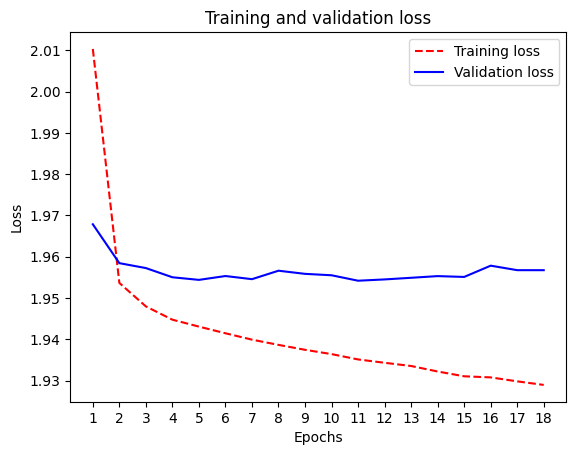

In [20]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'r--', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.xticks(epochs)
plt.ylabel('Loss')
plt.legend()

plt.show()

In [21]:
import numpy as np

# Pick a random subset of validation data for permutation importance
rng = np.random.default_rng(42)
n_samples = min(10000, X_val_scaled.shape[0])

indices = rng.choice(X_val_scaled.shape[0], size=n_samples, replace=False)

X_val_sub = X_val_scaled[indices]
y_val_sub = y_val.iloc[indices] if hasattr(y_val, "iloc") else y_val[indices]

In [22]:
# define MAE scoring function for permutation importance
from sklearn.metrics import mean_absolute_error

def mae_scorer(model, X, y):
  y_pred = model.predict(X, batch_size=4096, verbose=0)
  return -mean_absolute_error(y, y_pred)  # negative because higher is better

mae_scorer(model, X_val_scaled, y_val)

-0.9641818689114822

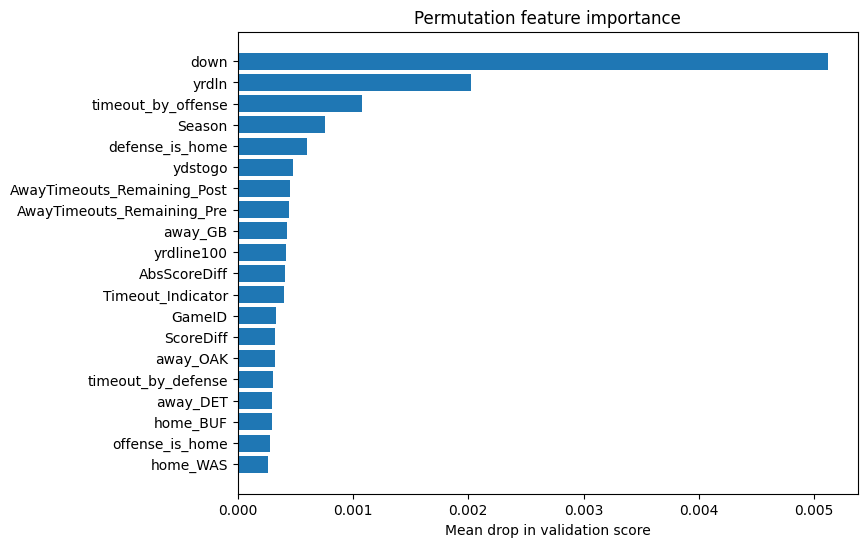

In [23]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_val_sub,
    y_val_sub,
    scoring=mae_scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=1
    )

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": result.importances_mean
    })

importance_df.sort_values(by="importance", ascending=False, inplace=True)

top_k = 20
plt.figure(figsize=(8,6))
plt.barh(importance_df["feature"].head(top_k)[::-1],
         importance_df["importance"].head(top_k)[::-1])
plt.xlabel("Mean drop in validation score")
plt.title("Permutation feature importance")
# plt.tight_layout()
plt.show()

In [24]:
results = model.evaluate(X_test_scaled, y_test, batch_size=256)
print("test loss, test acc:", results)

203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.9584 - mae: 0.9599 - mse: 1.9584
test loss, test acc: [1.9451059103012085, 0.9635049104690552, 1.9451059103012085]


In [25]:
# Obtain EPA predictions per play
y_pred = model.predict(X_test_scaled)

1622/1622 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [26]:
# Add predictions back into test dataframe
test_df = test_df.copy()
test_df['EPA_pred'] = y_pred
test_df['EPA_true'] = y_test

In [27]:
# Aggregate per game
game_results = test_df.groupby("GameID")[["EPA_true", "EPA_pred"]].sum()
# Mean absolute EPA error per game
game_results["game_MAE"] = (game_results["EPA_true"] - game_results["EPA_pred"]).abs()
overall_game_MAE = game_results["game_MAE"].mean()
print(f"Overall game MAE: {overall_game_MAE}")

Overall game MAE: 16.699629366657224
